C:\Users\miran\AppData\Local\Temp\ipykernel_88056\42652933.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dept_stats.index, y=dept_stats.values, palette='viridis')


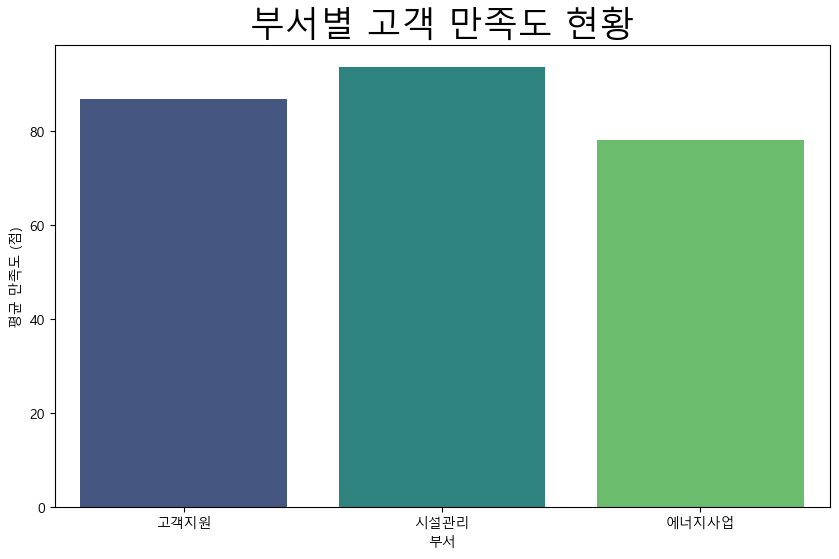

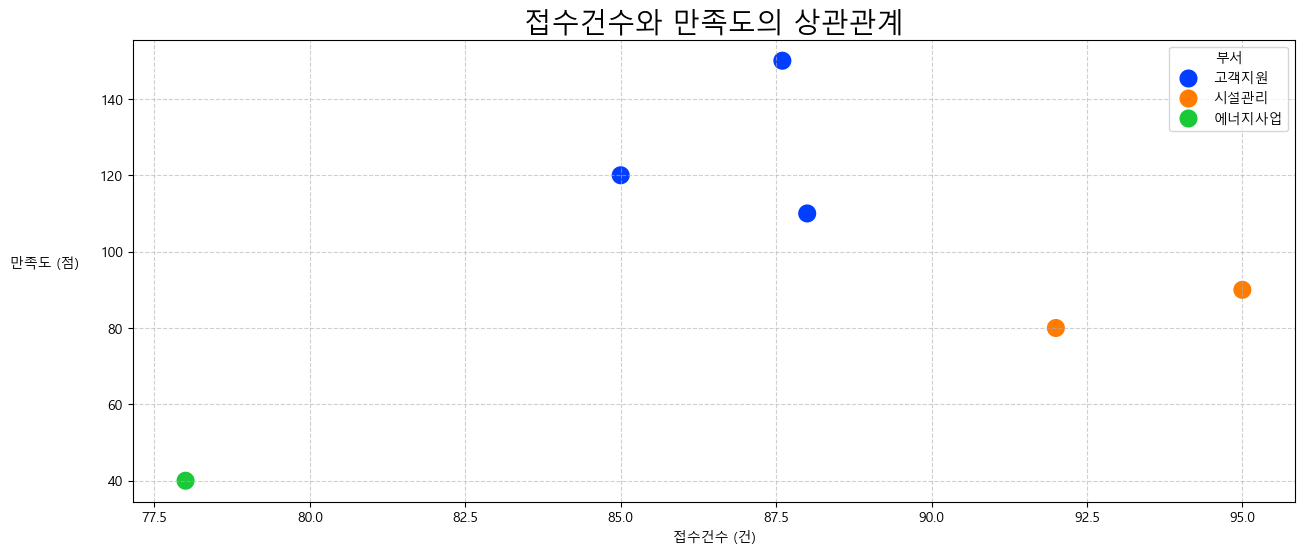

In [ ]:
import pandas as pd           # 데이터 표(DataFrame)를 다루는 라이브러리
import matplotlib.pyplot as plt # 기본 그래프를 그리는 도구
import seaborn as sns          # Matplotlib 기반의 세련된 시각화 라이브러리

# 1. 가상 데이터 생성 (전처리 실습용)
data = {
    '부서': ['고객지원', '시설관리', '고객지원', '에너지사업', '시설관리', '고객지원'],
    '만족도': [85, 92, None, 78, 95, 88], # None은 데이터가 비어있는 '결측치'를 의미
    '접수건수': [120, 80, 150, 40, 90, 110]
}
df = pd.DataFrame(data) # 딕셔너리 형태의 데이터를 판다스 표(DataFrame) 형태로 변환

# 2. 전처리: 비어있는 만족도를 평균값으로 채우기
# '만족도' 컬럼의 빈 칸(NaN)을 찾아 전체 만족도의 🍋평균값으로 채워넣음
# 만족도' 컬럼에 있는 숫자들의 평균(예: 85, 92, 78, 95, 88의 평균값인 87.6)을 계산
df['만족도'] = df['만족도'].fillna(df['만족도'].mean())

# 3. 통계 분석: 부서별 평균 만족도 계산
# '부서'별로 데이터를 그룹 묶고, 각 그룹의 🍋'만족도' 평균을 계산하여 저장
dept_stats = df.groupby('부서')['만족도'].mean()

# 4. 시각화 (한글 설정 필수)
plt.rcParams['font.family'] = 'Malgun Gothic' # 그래프 내 한글 깨짐 방지를 위해 '맑은 고딕' 폰트 설정
plt.figure(figsize=(10, 6)) # 가로 10인치, 세로 6인치 크기의 그래프 도화지 준비

# 부서별 만족도 막대 그래프 그리기
# x축은 부서 이름(index), y축은 계산된 평균값(values), 색상 테마는 'viridis' 적용
sns.barplot(x=dept_stats.index, y=dept_stats.values, palette='viridis')

plt.title('부서별 고객 만족도 현황', fontsize=25) # 그래프 제목 설정 및 글자 크기 지정
plt.ylabel('평균 만족도 (점)')                  # y축의 이름(레이블) 설정
plt.show()                                     # 최종적으로 완성된 그래프를 화면에 출력



# 🟠💡 코드 포인트
# hue='부서': 부서별로 점 색깔을 자동으로. (시각화의 핵심!)
# s=200: 점 크기를 시원하게 키웠습니다. 🟠1️⃣500으로 해보기
# plt.grid(): 격자 무늬 점이 정확히 몇 점대인지 읽기가 훨씬 수월

# 5. 상관관계 분석을 위한 산점도(Scatter Plot) 시각화
plt.figure(figsize=(15, 6)) # 🍋2️⃣p383 도화지 가로 12로도 바꿔보기

# 산점도 그리기 (x축: 접수건수, y축: 만족도)
# hue='부서'를 넣으면 부서별로 점 색깔을 다르게 표시.
# s=100은 점의 크기(size)
sns.scatterplot(data=df, x='만족도', y='접수건수', hue='부서', s=200, palette='bright')

# 그래프 제목 및 축 레이블 설정 🟠3️⃣x와 y축 바꿔보기
plt.title('접수건수와 만족도의 상관관계', fontsize=20)
plt.xlabel('접수건수 (건)')
plt.ylabel('만족도 (점)', rotation=0, labelpad=40) # 글자 똑바로 세우기 적용

plt.grid(True, linestyle='--', alpha=0.6) # 눈금선 추가해서 읽기 편하게 만들기

# 그래프 이름 지정 4️⃣저장! 🍋plt.show()보다 먼저 실행되어야
plt.savefig('result_chart.png', dpi=300, bbox_inches='tight')

plt.show()
